In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
import random

BASE_URL = "https://traveltriangle.com/tour-packages/india/page/{}"

headers = {
    "User-Agent": "Mozilla/5.0"
}

all_data = []

for page in range(1, 61):

    print(f"Scraping Page {page}...")

    url = BASE_URL.format(page)

    try:
        response = requests.get(url, headers=headers, timeout=20)

        if response.status_code != 200:
            print(f"Failed Page {page}")
            continue

        soup = BeautifulSoup(response.text, "lxml")

        cards = soup.find_all("div",class_="clearfix container mb15 border at_packagecard_wrapper radius10 relative")

        print(f"Packages Found: {len(cards)}")

        for card in cards:

            # Package Name
            try:
                package_name = card.find("p",class_="at_packageName").get_text(strip=True)
            except:
                package_name = None

            # Days & Nights
            try:
                duration = card.find("span",class_="at_package_duration").get_text(" ", strip=True)

                nums = re.findall(r"\d+", duration)

                days = int(nums[0])
                nights = int(nums[1])

            except:
                days = None
                nights = None

            # Current Price
            try:
                price_tag = card.find("p",class_="sfc3 m0 f20 fw9 priceVal at_newprice")

                current_price = price_tag.find(string=True, recursive=False)

                current_price = re.search(r"\d[\d,]*",current_price).group()

                current_price = int(current_price.replace(",", ""))

            except:
                current_price = None

            # Old Price
            try:
                old_price = card.find("span",class_="at_oldprice").get_text(strip=True)

                old_price = int(re.search(r"\d[\d,]*", old_price).group().replace(",", ""))

            except:
                old_price = None

            # Discount
            try:
                discount = int(re.search(r"\d+",card.find("span",class_="at_discount_label").get_text()).group())

            except:
                discount = None

            # Hotel Rating
            try:
                hotel_rating = card.find("input",
                    class_="radio-common-circle at_packagehotel_rating",
                    checked=True
                ).find_next("label").get_text(strip=True)

                hotel_rating = int(re.search(r"\d+", hotel_rating).group())

            except:
                hotel_rating = None

            # Cities Covered
            try:
                cities = card.find("ul",class_="at_packagecity_list")

                city_list = []

                for city in cities.find_all("li"):
                    city_name = re.sub(r"\(\d+D\)","",city.get_text(" ", strip=True)).strip()

                    city_list.append(city_name)

                cities_covered = ", ".join(city_list)

            except:
                cities_covered = None

            # Destination
            try:
                destination = cities_covered.split(",")[0].strip()
            except:
                destination = None

            all_data.append({
                "Package Name": package_name,
                "Destination": destination,
                "Days": days,
                "Nights": nights,
                "Current Price": current_price,
                "Old Price": old_price,
                "Discount": discount,
                "Hotel Rating": hotel_rating,
                "Cities Covered": cities_covered
            })

        # Delay between requests
        time.sleep(random.uniform(2, 4))

    except Exception as e:
        print(f"Error on Page {page}: {e}")

print("Scraping Completed!")

df = pd.DataFrame(all_data)

print(df.shape)

df.to_csv("travel_packages.csv", index=False)

print(df.head())

In [ ]:
#🚀 Sprint 1 – Travel Package Market Analysis
🎯 Business Understanding & Data Loading
Objective: Analyze travel packages to identify pricing trends, destination popularity, and value-for-money offerings.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv('travel_packages.csv')

# Initial exploration
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (880, 9)


# DATA UNDERSTANDING

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Package Name    880 non-null    object 
 1   Destination     880 non-null    object 
 2   Days            880 non-null    int64  
 3   Nights          880 non-null    int64  
 4   Current Price   880 non-null    int64  
 5   Old Price       879 non-null    float64
 6   Discount        879 non-null    float64
 7   Hotel Rating    878 non-null    float64
 8   Cities Covered  880 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 62.0+ KB


In [5]:
df.head(5)

,Package Name,Destination,Days,Nights,Current Price,Old Price,Discount,Hotel Rating,Cities Covered
0,Most Reasonable Goa Honeymoon Tour Packages,Goa,5,4,7999,9142.0,13.0,2.0,Goa
1,"Andaman Honeymoon Package - Port Blair, Havelock",Port Blair,5,4,15599,18811.0,17.0,3.0,"Port Blair, Havelock"
2,Romantic Mussoorie Tour Package From Delhi,Mussoorie,3,2,10500,12000.0,13.0,3.0,Mussoorie
3,Coorg Package For 2 Nights And 3 Days,Coorg,3,2,14500,15934.0,9.0,3.0,Coorg
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,Port Blair,5,4,33200,36484.0,9.0,3.0,"Port Blair, Havelock"


In [7]:
# 3. Numerical and Categorical Variables
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
display(numerical_cols)

print("\nCategorical Features:")
display(categorical_cols)

Numerical Features:


['Days', 'Nights', 'Current Price', 'Old Price', 'Discount', 'Hotel Rating']


Categorical Features:


['Package Name', 'Destination', 'Cities Covered']

In [8]:
# 4. Summary Statistics for Numerical Variables
df[numerical_cols].describe()

,Days,Nights,Current Price,Old Price,Discount,Hotel Rating
count,880.000000,880.000000,880.000000,879.000000,879.000000,878.000000
mean,4.742045,3.742045,20828.601136,22935.698521,9.249147,2.995444
std,2.054559,2.054559,15637.899528,17115.119454,2.853371,0.588741
min,2.000000,1.000000,2199.000000,2365.000000,1.000000,2.000000
25%,3.000000,2.000000,11590.000000,12736.000000,8.000000,3.000000
50%,4.000000,3.000000,16499.000000,18163.000000,9.000000,3.000000
75%,6.000000,5.000000,24999.000000,27483.000000,9.000000,3.000000
max,14.000000,13.000000,167999.000000,182608.000000,36.000000,5.000000


# DATA CLEANING

In [9]:
# Check for missing values
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


Package Name      0
Destination       0
Days              0
Nights            0
Current Price     0
Old Price         1
Discount          1
Hotel Rating      2
Cities Covered    0
dtype: int64

In [10]:
#Handling missing values
df["Old Price"] = df["Old Price"].fillna(df["Old Price"].median())

df["Discount"] = df["Discount"].fillna(df["Discount"].median())

df["Hotel Rating"] = df["Hotel Rating"].fillna(df["Hotel Rating"].median())

In [11]:
# Verifying the result
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


Package Name      0
Destination       0
Days              0
Nights            0
Current Price     0
Old Price         0
Discount          0
Hotel Rating      0
Cities Covered    0
dtype: int64

In [12]:
# Identify duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate records found: {duplicates}")

Number of duplicate records found: 0


In [13]:
# Create 'Price Difference' feature
df['Price Difference'] = df['Old Price'] - df['Current Price']
print("First 5 rows with 'Price Difference':")
display(df[['Old Price', 'Current Price', 'Price Difference']].head())

First 5 rows with 'Price Difference':


,Old Price,Current Price,Price Difference
0,9142.0,7999,1143.0
1,18811.0,15599,3212.0
2,12000.0,10500,1500.0
3,15934.0,14500,1434.0
4,36484.0,33200,3284.0


In [14]:
# Standardize 'Destination' and 'Cities Covered'
df['Destination'] = df['Destination'].str.lower().str.strip()
df['Cities Covered'] = df['Cities Covered'].str.lower().str.strip()

In [15]:
display(df[['Destination', 'Cities Covered']].head())

,Destination,Cities Covered
0,goa,goa
1,port blair,"port blair, havelock"
2,mussoorie,mussoorie
3,coorg,coorg
4,port blair,"port blair, havelock"


In [16]:
# Create 'Number of Cities' feature
df['Number of Cities'] = df['Cities Covered'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)
print("First 5 rows with 'Number of Cities':")
display(df[['Cities Covered', 'Number of Cities']].head())

First 5 rows with 'Number of Cities':


,Cities Covered,Number of Cities
0,goa,1
1,"port blair, havelock",2
2,mussoorie,1
3,coorg,1
4,"port blair, havelock",2


In [17]:
print("DataFrame Info after Feature Engineering:")
display(df.info())

print("First 5 rows of DataFrame after Feature Engineering:")
display(df.head())

DataFrame Info after Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Package Name      880 non-null    object 
 1   Destination       880 non-null    object 
 2   Days              880 non-null    int64  
 3   Nights            880 non-null    int64  
 4   Current Price     880 non-null    int64  
 5   Old Price         880 non-null    float64
 6   Discount          880 non-null    float64
 7   Hotel Rating      880 non-null    float64
 8   Cities Covered    880 non-null    object 
 9   Price Difference  880 non-null    float64
 10  Number of Cities  880 non-null    int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 75.8+ KB


None

First 5 rows of DataFrame after Feature Engineering:


,Package Name,Destination,Days,Nights,Current Price,Old Price,Discount,Hotel Rating,Cities Covered,Price Difference,Number of Cities
0,Most Reasonable Goa Honeymoon Tour Packages,goa,5,4,7999,9142.0,13.0,2.0,goa,1143.0,1
1,"Andaman Honeymoon Package - Port Blair, Havelock",port blair,5,4,15599,18811.0,17.0,3.0,"port blair, havelock",3212.0,2
2,Romantic Mussoorie Tour Package From Delhi,mussoorie,3,2,10500,12000.0,13.0,3.0,mussoorie,1500.0,1
3,Coorg Package For 2 Nights And 3 Days,coorg,3,2,14500,15934.0,9.0,3.0,coorg,1434.0,1
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,port blair,5,4,33200,36484.0,9.0,3.0,"port blair, havelock",3284.0,2


In [18]:
df['Package Name'] = df['Package Name'].str.lower().str.strip()

# outlier Analysis

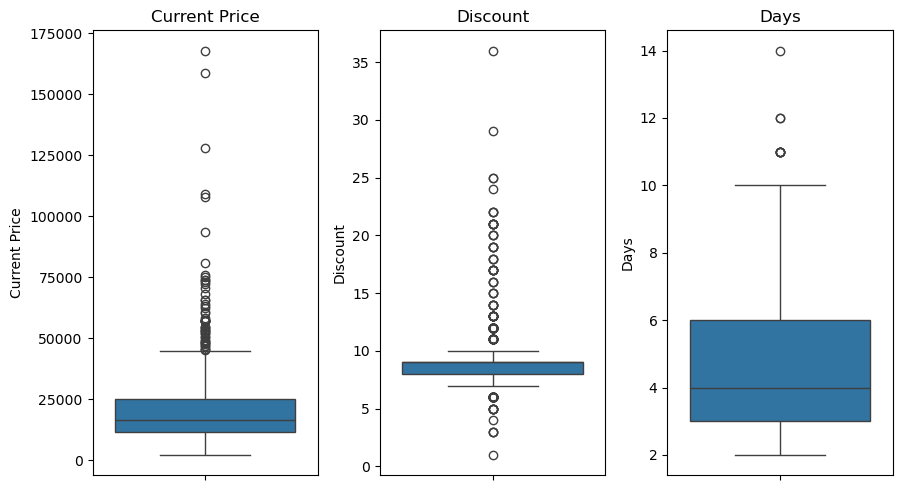

In [19]:

outlier_features = ["Current Price", "Discount", "Days"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(outlier_features, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
def detect_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect and report outliers for each feature
for col in outlier_features:
    outliers, lower_bound, upper_bound = detect_iqr_outliers(df, col)
    print(f"\n--- Outliers for {col} ---")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    if not outliers.empty:
        display(outliers[[col]].head()) # Display first few outlier values
    else:
        print("No outliers detected.")


--- Outliers for Current Price ---
Number of outliers: 52
Lower Bound: -8523.50, Upper Bound: 45112.50


,Current Price
29,68000
32,72122
39,45663
54,62399
169,63455



--- Outliers for Discount ---
Number of outliers: 178
Lower Bound: 6.50, Upper Bound: 10.50


,Discount
0,13.0
1,17.0
2,13.0
8,17.0
9,16.0



--- Outliers for Days ---
Number of outliers: 9
Lower Bound: -1.50, Upper Bound: 10.50


,Days
159,11
198,11
440,12
545,12
574,11


# Exploring numerical features

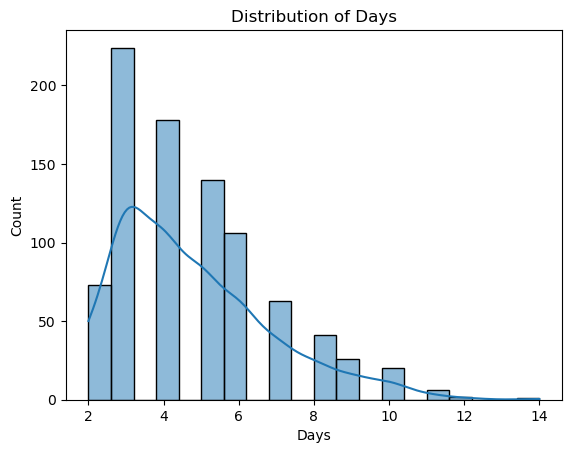

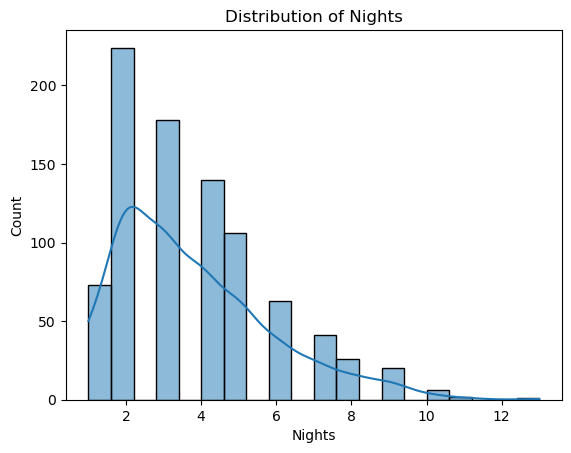

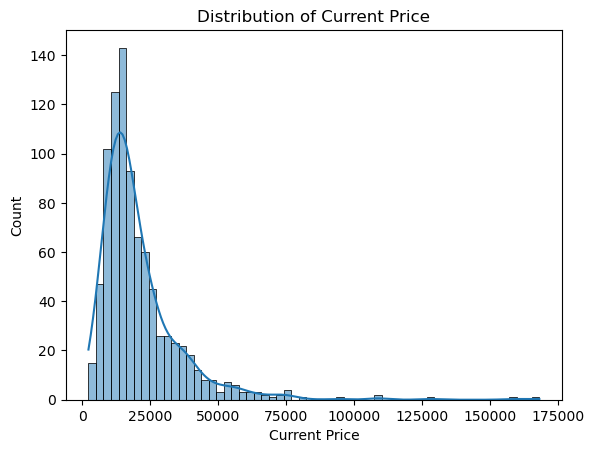

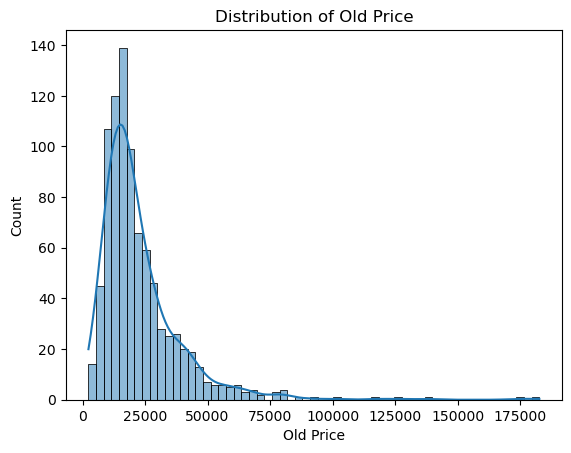

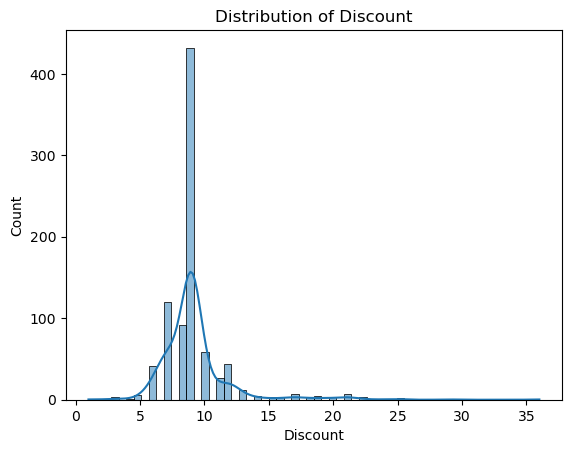

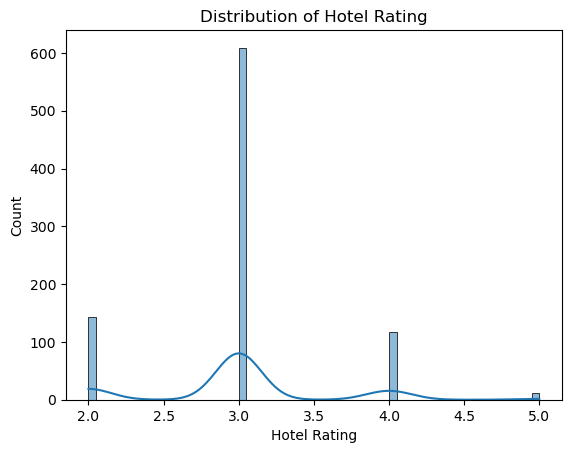

In [21]:

for col in numerical_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [34]:
df["Price Difference"] = df["Old Price"] - df["Current Price"]

df["Price Per Day"] = df["Current Price"] / df["Days"]

df["Number of Cities"] = df["Cities Covered"].apply(
    lambda x: len(x.split(",")) if pd.notna(x) else 0
)

In [35]:
def price_category(price):
    if price < 15000:
        return "Budget"
    elif price < 30000:
        return "Standard"
    else:
        return "Premium"

df["Price Category"] = df["Current Price"].apply(price_category)

In [36]:
def trip_length(days):
    if days <= 3:
        return "Short"
    elif days <= 6:
        return "Medium"
    else:
        return "Long"

df["Trip Length"] = df["Days"].apply(trip_length)

# Business Question:

 ## 1. Which destinations have the highest package availability on TravelTriangle?

In [37]:
destination_count = df["Destination"].value_counts().head(10)

print(destination_count)

Destination
munnar      66
gangtok     42
goa         39
shimla      38
srinagar    35
ooty        31
manali      29
leh         28
coorg       27
shillong    23
Name: count, dtype: int64


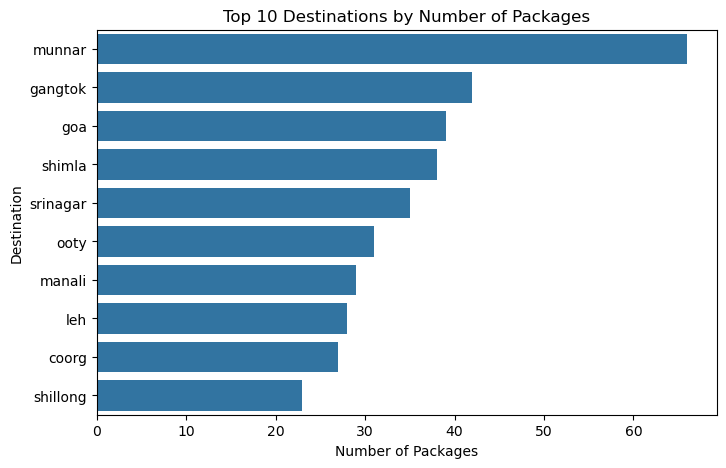

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=destination_count.values,
    y=destination_count.index
)

plt.title("Top 10 Destinations by Number of Packages")
plt.xlabel("Number of Packages")
plt.ylabel("Destination")
plt.show()

## Interpretation :
### The analysis shows that [munnar] has the highest number of packages, followed by [gangtok] and [goa]. This indicates that these destinations have a strong presence in TravelTriangle's package offerings.

# Q2. Which destinations are the most expensive?
## Business Question: 

## Which destinations have the highest average travel package prices?

In [39]:
destination_price = (
    df.groupby("Destination")["Current Price"]
    .agg(["mean", "median", "count"])
)

destination_price = destination_price[
    destination_price["count"] >= 5
].sort_values("mean", ascending=False)

print(destination_price.head(10))

                     mean   median  count
Destination                              
gangtok      43646.261905  39805.0     42
dalhousie    36954.857143  38591.0      7
darjeeling   35505.461538  24028.0     13
bhalukpong   34433.000000  36499.5      6
new delhi    32904.136364  19000.0     22
srinagar     32560.085714  23000.0     35
katra        30558.500000  30225.0      8
jaipur       29773.105263  25999.0     19
leh          28688.178571  26499.0     28
shimla       28270.842105  26179.5     38


# Visualization

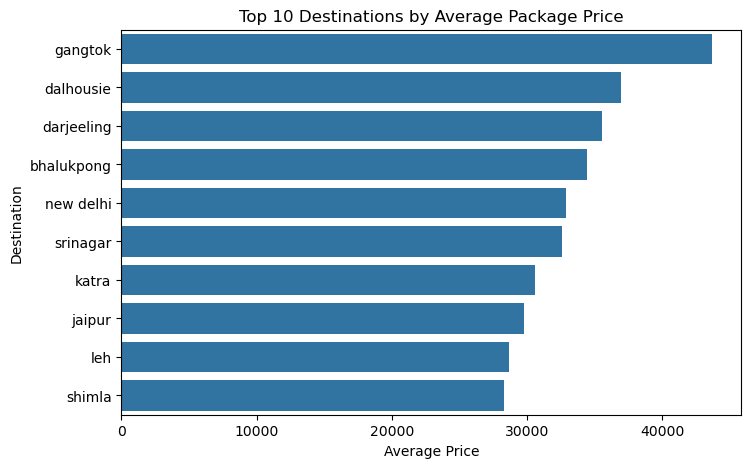

In [40]:
top_expensive = destination_price.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_expensive["mean"],
    y=top_expensive.index
)

plt.title("Top 10 Destinations by Average Package Price")
plt.xlabel("Average Price")
plt.ylabel("Destination")
plt.show()

# Interpretation

## [gangtok] has the highest average package price among destinations with sufficient package representation. This suggests that packages offered for this destination are positioned at a relatively higher price point.

# Q3. Which destinations provide the best value for money?


### Business Question

### Which destinations provide the lowest package cost per travel day?

In [43]:
value_by_destination = (df.groupby("Destination")["Price Per Day"].agg(["mean", "median", "count"]))

value_by_destination = value_by_destination[value_by_destination["count"] >= 5].sort_values("mean")

print(value_by_destination.head(10))

                     mean       median  count
Destination                                  
jaisalmer     2333.200000  2499.333333      5
kovalam       2954.358333  3005.000000      6
udaipur       2994.703175  2999.750000     21
mount abu     3014.142857  2666.666667      7
haridwar      3063.349915  3325.000000     14
munnar        3204.788745  2888.250000     66
cochin        3213.809354  2836.171429     14
kochi         3227.417196  2837.714286     12
bhubaneshwar  3346.297959  3509.800000      7
nainital      3371.151786  3412.500000     14


# Visualization

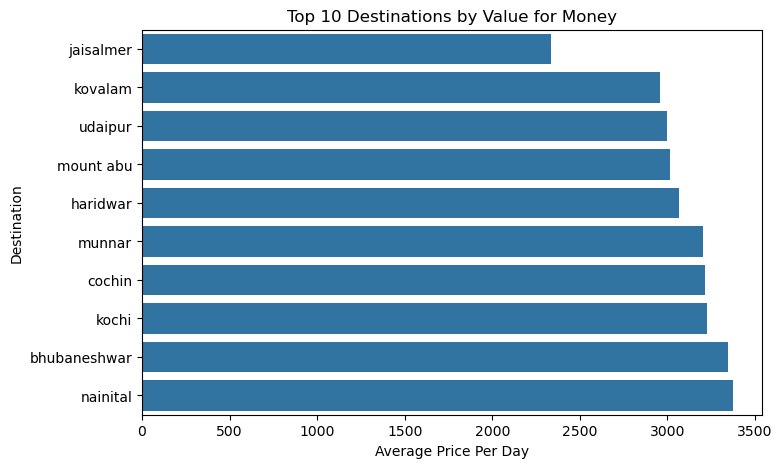

In [42]:
top_value = value_by_destination.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_value["mean"],
    y=top_value.index
)

plt.title("Top 10 Destinations by Value for Money")
plt.xlabel("Average Price Per Day")
plt.ylabel("Destination")
plt.show()

# Interpretation

## [jaisalmer] has the lowest average price per day, indicating that travelers can potentially obtain a lower daily package cost compared with other destinations.

# Q4. Does trip duration affect package price?

## Business Question:

## Is longer trip duration associated with higher package prices?

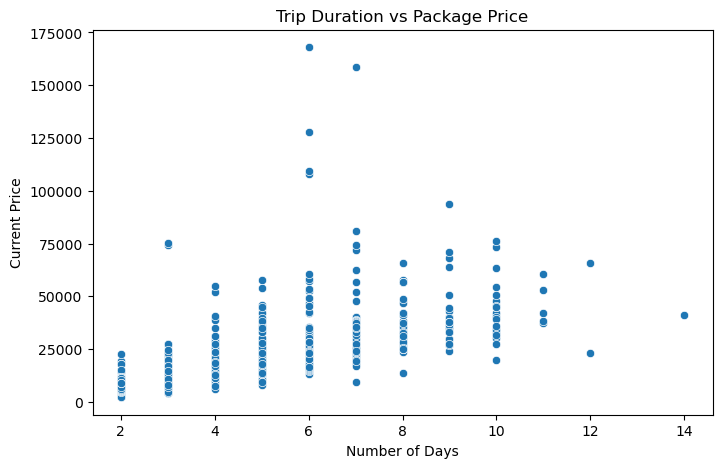

In [44]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Days",
    y="Current Price"
)

plt.title("Trip Duration vs Package Price")
plt.xlabel("Number of Days")
plt.ylabel("Current Price")
plt.show()

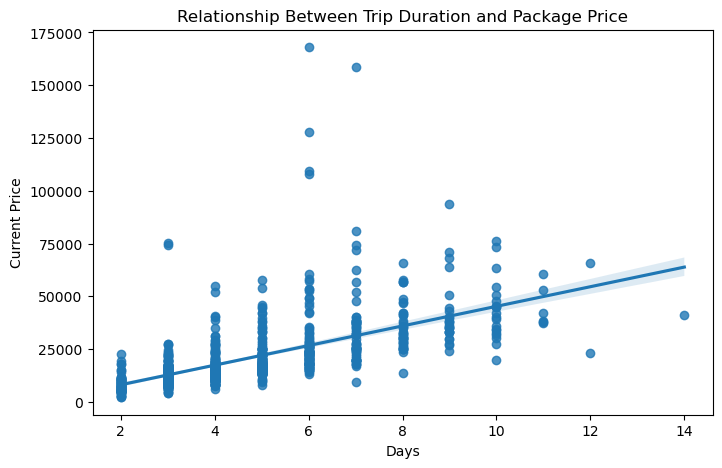

In [45]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Days",
    y="Current Price"
)

plt.title("Relationship Between Trip Duration and Package Price")
plt.xlabel("Days")
plt.ylabel("Current Price")
plt.show()

# Pearson Corelation

In [48]:
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import linregress

In [50]:
correlation, p_value = pearsonr(
    df["Days"],
    df["Current Price"]
)

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.6104717401669288
P-value: 5.528400685314052e-91


The correlation between trip duration and package price is [0.6104717401669288], indicating a [weak/moderate/strong] positive relationship. The p-value is [5.528400685314052e-9]. Since the p-value is [greater] than 0.05, the relationship is [not statistically significant].

# Q5. Does hotel rating affect package price?
## Business Question:

## Are packages with higher hotel ratings significantly more expensive?

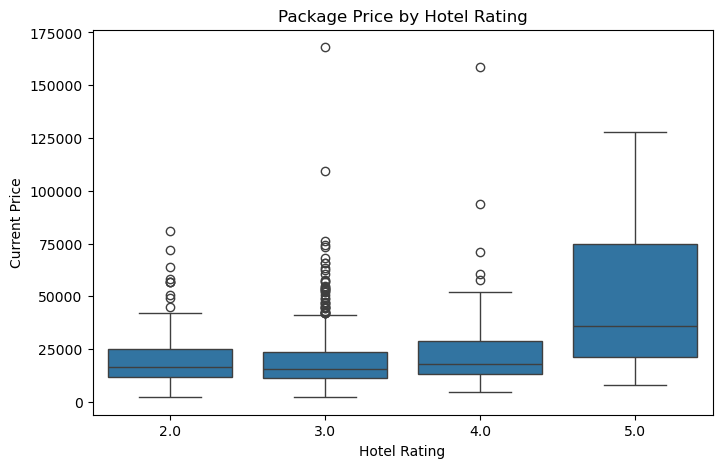

In [51]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Hotel Rating",
    y="Current Price"
)

plt.title("Package Price by Hotel Rating")
plt.xlabel("Hotel Rating")
plt.ylabel("Current Price")
plt.show()

In [52]:
hotel_price = (
    df.groupby("Hotel Rating")["Current Price"]
    .agg(["mean", "median", "count"])
)

print(hotel_price)

                      mean   median  count
Hotel Rating                              
2.0           20538.517483  16499.0    143
3.0           19757.658456  15599.0    609
4.0           23955.076923  18127.0    117
5.0           50636.636364  35990.0     11


In [53]:
groups = [
    group["Current Price"].dropna()
    for name, group in df.groupby("Hotel Rating")
]

anova_stat, anova_p = f_oneway(*groups)

print("F-statistic:", anova_stat)
print("P-value:", anova_p)

F-statistic: 16.69897196593239
P-value: 1.478511055476187e-10


Hypotheses

H₀: Average package prices are equal across hotel-rating groups.

H₁: At least one hotel-rating group has a different average package price.

 Since p_value > 0.05 we will accept the null hypothesis

There is insufficient statistical evidence to conclude that average package price differs across hotel-rating groups


# Q6. Which destinations offer the highest discounts?
## Business Question:

## Which destinations have the highest average promotional discounts?

In [54]:
discount_by_destination = (
    df.groupby("Destination")["Discount"]
    .agg(["mean", "median", "count"])
)

discount_by_destination = discount_by_destination[
    discount_by_destination["count"] >= 5
].sort_values("mean", ascending=False)

print(discount_by_destination.head(10))

                   mean  median  count
Destination                           
calangute     14.777778    13.0      9
jaipur        10.894737     9.0     19
munnar        10.348485     9.0     66
dalhousie     10.285714     9.0      7
port blair    10.000000     9.0     22
bhubaneshwar  10.000000     9.0      7
kaziranga     10.000000     9.0      5
jamnagar      10.000000     9.5      6
udaipur        9.904762     9.0     21
cochin         9.714286     9.0     14


# Visualization


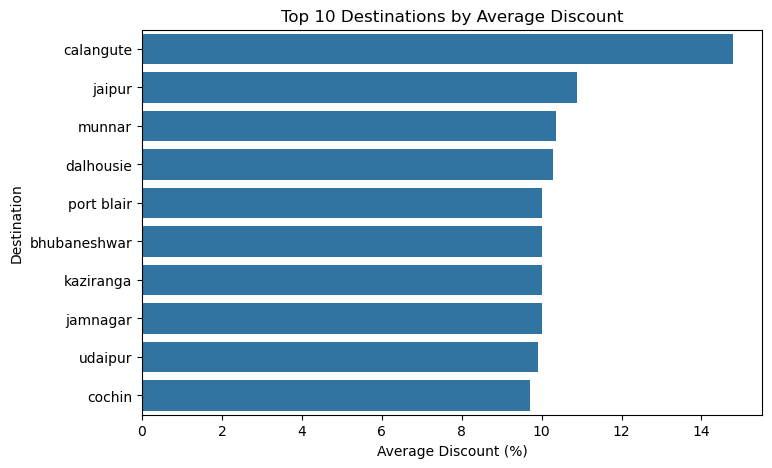

In [55]:
top_discount = discount_by_destination.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_discount["mean"],
    y=top_discount.index
)

plt.title("Top 10 Destinations by Average Discount")
plt.xlabel("Average Discount (%)")
plt.ylabel("Destination")
plt.show()

[calanguate] has the highest average discount among destinations with sufficient package representation.

# 07. Correlation Heatmap

## This will bring your numerical analysis together.

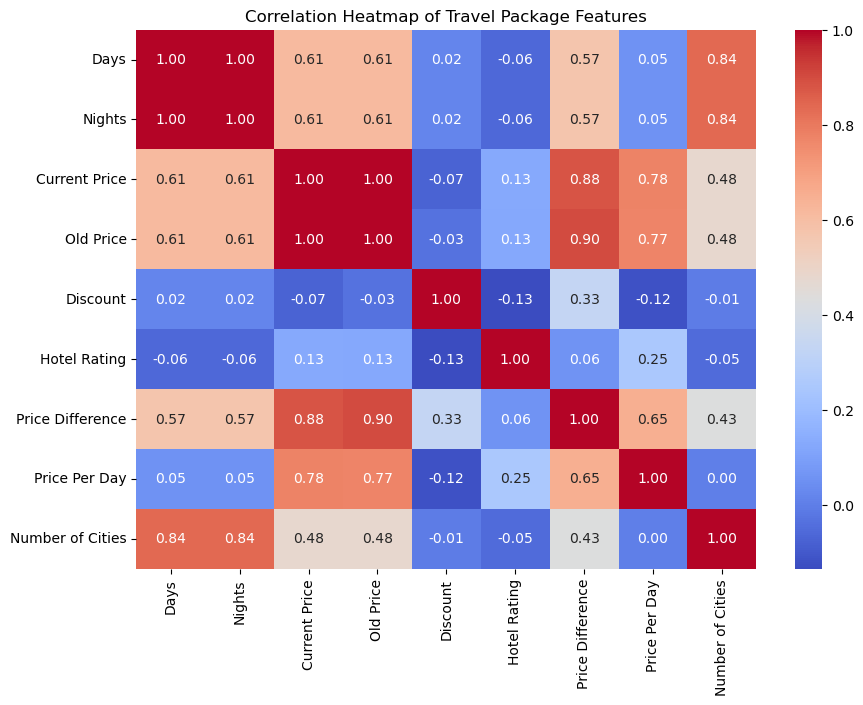

In [56]:
numeric_cols = [
    "Days",
    "Nights",
    "Current Price",
    "Old Price",
    "Discount",
    "Hotel Rating",
    "Price Difference",
    "Price Per Day",
    "Number of Cities"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Travel Package Features")
plt.show()

# 08. Independent t-Test

## Your t-test should compare two groups only.

## For example, compare 3-star and 4-star packages.

In [57]:
print(df["Hotel Rating"].value_counts())

Hotel Rating
3.0    609
2.0    143
4.0    117
5.0     11
Name: count, dtype: int64


In [58]:
group_3 = df[
    df["Hotel Rating"] == 3
]["Current Price"].dropna()

group_4 = df[
    df["Hotel Rating"] == 4
]["Current Price"].dropna()

In [59]:
t_stat, p_value = ttest_ind(
    group_3,
    group_4,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.295279352604731
P-value: 0.023185989899178146


Hypotheses

H₀: Mean package prices for 3-star and 4-star packages are equal.

H₁: Mean package prices are different.

Interpretation :

p-value < 0.05

Reject H₀. There is statistically significant evidence that the average prices of 3-star and 4-star packages differ.

# 09. Chi-Square Test
## Business Question

## Is hotel rating associated with package price category?

In [60]:
table = pd.crosstab(
    df["Hotel Rating"],
    df["Price Category"]
)

print(table)

Price Category  Budget  Premium  Standard
Hotel Rating                             
2.0                 60       25        58
3.0                271       98       240
4.0                 39       28        50
5.0                  2        6         3


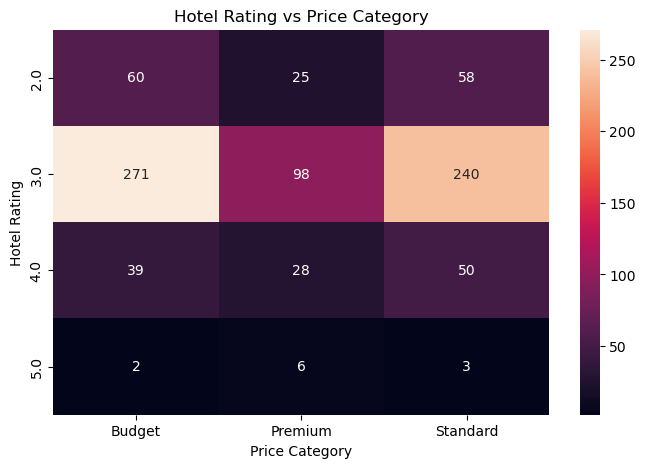

In [62]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    table,
    annot=True,
    fmt="d"
)

plt.title("Hotel Rating vs Price Category")
plt.xlabel("Price Category")
plt.ylabel("Hotel Rating")
plt.show()

# 10 . chi square test

In [63]:
chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 16.961036049146422
P-value: 0.009427514344961242
Degrees of freedom: 6


Hypotheses

H₀: Hotel rating and price category are independent.

H₁: Hotel rating and price category are associated.

Interpretation :

p-value < 0.05

Reject H₀. There is statistically significant evidence of an association between hotel rating and package price category.